# Math And Dense-Sparse Validation

Executable checks for the Lie groups, left-perturbation Jacobians,
whitening, scaling, projection, Schur reduction, and dense/sparse
invariants used by the observability package.

**Notebook notation.** Tangents are rotation-first and all pose perturbations
are left perturbations:

$$
\xi =
\begin{bmatrix}
\omega \\
v
\end{bmatrix}
\in \mathbb{R}^6,
\qquad
T'=\operatorname{Exp}(\delta\xi)T,
\qquad
R'=\operatorname{Exp}(\delta\omega)R.
$$

For every numerical comparison, the notebook records

$$
e_\infty=\max_{ij}|A_{ij}-B_{ij}|,
\qquad
e_{\mathrm{rel}}=
\frac{\|A-B\|}{\max(\|B\|,\epsilon)}.
$$

In [1]:
from pathlib import Path
import sys, time
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "outputs" / "math_validation"
OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

from calib_observability.lie_so3 import *
from calib_observability.lie_se3 import *
from calib_observability.lie_se2 import *
from calib_observability.finite_difference import finite_difference_left_jacobian_se3, finite_difference_left_jacobian_se2
from calib_observability.residuals import *
from calib_observability.jacobians import *
from calib_observability.whitening import whiten_residual_and_jacobian_dense
from calib_observability.scaling import ParameterScales, build_parameter_scaling_dense, build_parameter_scaling_sparse, scale_jacobian_dense, scale_jacobian_sparse
from calib_observability.assembly import VariableLayout, JacobianBlock, assemble_jacobian_dense, assemble_jacobian_sparse, make_residual_blocks
from calib_observability.linalg import *
from calib_observability.observability import *
from calib_observability.plotting import save_singular_values_plot, save_sparsity_plot

rng = np.random.default_rng(123)
errors = []

def record(name, A, B, atol=1e-6, rtol=1e-5):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    max_abs = float(np.max(np.abs(A - B))) if A.size else 0.0
    rel = float(np.linalg.norm(A - B) / max(np.linalg.norm(B), 1e-15))
    errors.append((name, max_abs, rel))
    assert max_abs <= atol or rel <= rtol, (name, max_abs, rel)
    return max_abs, rel

## 1. Imports And Reproducibility

The validation run stores each check as an entry of

$$
\mathcal{E}
=
\left\{
\left(\mathrm{name}_i,e_{\infty,i},e_{\mathrm{rel},i}\right)
\right\}_{i=1}^{N},
$$

using a fixed random seed so repeated notebook executions exercise the same
randomized perturbations.

In [2]:
assert rng is not None
print('output directory:', OUT)

output directory: /home/camel/Skoltech/phd_proposal/outputs/math_validation


## 2. SO(3) Exp/Log Round-Trip Tests

For $\omega\in\mathbb{R}^3$, let $[\omega]_\times x=\omega\times x$ and
$\theta=\|\omega\|$. The implementation checks the Rodrigues exponential

$$
\operatorname{Exp}_{\mathrm{SO}(3)}(\omega)
=
I
+\frac{\sin\theta}{\theta}[\omega]_\times
+\frac{1-\cos\theta}{\theta^2}[\omega]_\times^2
$$

against the round-trip identities

$$
\operatorname{Log}_{\mathrm{SO}(3)}
\left(\operatorname{Exp}_{\mathrm{SO}(3)}(\omega)\right)
=
\omega,
\qquad
\operatorname{Exp}_{\mathrm{SO}(3)}
\left(\operatorname{Log}_{\mathrm{SO}(3)}(R)\right)
=
R.
$$

In [3]:
for _ in range(50):
    omega = rng.normal(0.0, 0.35, 3)
    R = so3_exp(omega)
    record("SO3 Log(Exp)", so3_log(R), omega, atol=1e-10)
    record("SO3 Exp(Log)", so3_exp(so3_log(R)), R, atol=1e-10)

## 3. SE(3) Exp/Log Round-Trip Tests

For the rotation-first tangent $\xi=[\omega^\top,v^\top]^\top$,

$$
\operatorname{Exp}_{\mathrm{SE}(3)}(\xi)
=
\begin{bmatrix}
\operatorname{Exp}_{\mathrm{SO}(3)}(\omega) & J_l(\omega)v \\
0 & 1
\end{bmatrix}.
$$

The test verifies

$$
\operatorname{Log}_{\mathrm{SE}(3)}
\left(\operatorname{Exp}_{\mathrm{SE}(3)}(\xi)\right)=\xi,
\qquad
\operatorname{Exp}_{\mathrm{SE}(3)}
\left(\operatorname{Log}_{\mathrm{SE}(3)}(T)\right)=T.
$$

In [4]:
for _ in range(40):
    xi = rng.normal(0.0, [0.2, 0.2, 0.2, 0.5, 0.5, 0.5])
    T = se3_exp(xi)
    record("SE3 Log(Exp)", se3_log(T), xi, atol=1e-9)
    record("SE3 Exp(Log)", se3_exp(se3_log(T)), T, atol=1e-10)

## 4. SE(2) Exp/Log Round-Trip Tests

For $\xi=[\theta,v_x,v_y]^\top$ and $v=[v_x,v_y]^\top$,

$$
R(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta\\
\sin\theta & \cos\theta
\end{bmatrix},
\qquad
\operatorname{Exp}_{\mathrm{SE}(2)}(\xi)
=
\begin{bmatrix}
R(\theta) & V(\theta)v\\
0 & 1
\end{bmatrix}.
$$

The planar checks use the same inverse identities:

$$
\operatorname{Log}_{\mathrm{SE}(2)}
\left(\operatorname{Exp}_{\mathrm{SE}(2)}(\xi)\right)=\xi,
\qquad
\operatorname{Exp}_{\mathrm{SE}(2)}
\left(\operatorname{Log}_{\mathrm{SE}(2)}(T)\right)=T.
$$

In [5]:
for _ in range(40):
    xi = rng.normal(0.0, [0.3, 0.4, 0.4])
    T = se2_exp(xi)
    record("SE2 Log(Exp)", se2_log(T), xi, atol=1e-10)
    record("SE2 Exp(Log)", se2_exp(se2_log(T)), T, atol=1e-10)

## 5. Adjoint Identity Checks

The adjoint is verified through conjugation on the group:

$$
T\,\operatorname{Exp}(\eta)\,T^{-1}
=
\operatorname{Exp}\!\left(\operatorname{Ad}_{T}\eta\right),
$$

for both $\mathrm{SE}(3)$ and $\mathrm{SE}(2)$, using their respective tangent
dimensions.

In [6]:
xi = np.array([0.1, -0.2, 0.05, 0.3, -0.1, 0.2])
eta = np.array([-0.03, 0.04, 0.02, 0.1, 0.05, -0.02])
T = se3_exp(xi)
record("SE3 Adj identity", T @ se3_exp(eta) @ se3_inverse(T), se3_exp(se3_adjoint(T) @ eta), atol=1e-10)

xi2 = np.array([0.3, 0.2, -0.1])
eta2 = np.array([-0.05, 0.04, 0.02])
T2 = se2_exp(xi2)
record("SE2 Adj identity", T2 @ se2_exp(eta2) @ se2_inverse(T2), se2_exp(se2_adjoint(T2) @ eta2), atol=1e-10)

(2.220446049250313e-16, 1.8785490661737804e-16)

## 6. Left-Perturbation Checks

The left Jacobian $J_l$ is validated with the first-order perturbation rule

$$
\operatorname{Exp}(\xi+\delta)
\approx
\operatorname{Exp}\!\left(J_l(\xi)\delta\right)
\operatorname{Exp}(\xi),
$$

applied in both $\mathrm{SE}(3)$ and $\mathrm{SE}(2)$.

In [7]:
xi = np.array([0.08, -0.04, 0.03, 0.2, 0.1, -0.1])
delta = np.array([1e-5, -2e-5, 1.5e-5, 2e-5, -1e-5, 1e-5])
lhs = se3_exp(xi + delta)
rhs = se3_exp(se3_left_jacobian(xi) @ delta) @ se3_exp(xi)
record("SE3 left perturbation", lhs, rhs, atol=1e-9)

xi2 = np.array([0.2, 0.3, -0.2])
delta2 = np.array([1e-5, -2e-5, 1.5e-5])
lhs2 = se2_exp(xi2 + delta2)
rhs2 = se2_exp(se2_left_jacobian(xi2) @ delta2) @ se2_exp(xi2)
record("SE2 left perturbation", lhs2, rhs2, atol=1e-9)

(6.213918268827001e-12, 4.0481710836756495e-12)

## 7. Gyroscope Temporal-Offset Analytic Versus Finite Difference

The bias-corrected signal and shifted rotation increment are

$$
\omega_b(t)=\omega(t)-b_g,
\qquad
\phi_k(\tau)=
\int_{t_k+\tau}^{t_{k+1}+\tau}\omega_b(s)\,ds,
\qquad
\Delta R_k(\tau)=\operatorname{Exp}(\phi_k(\tau)).
$$

The propagation residual is

$$
r_k=
\operatorname{Log}
\left(
R_k\Delta R_k(\tau)R_{k+1}^{-1}
\right).
$$

With

$$
q_k=
\omega_b(t_{k+1}+\tau)-\omega_b(t_k+\tau),
$$

the analytic temporal-offset Jacobian checked against finite differences is

$$
\frac{\partial r_k}{\partial\tau}
=
J_l^{-1}(r_k)\,
R_k\,
J_l(\phi_k)\,
q_k.
$$

In [8]:
times = np.linspace(0.0, 2.0, 240)
omega = np.c_[0.01 * times, 0.02 * np.sin(times), 0.1 + 0.03 * times**2]
b_g = np.array([0.001, -0.002, 0.003])
t0, t1, tau = 0.3, 1.1, 0.02
R0 = np.eye(3)
R1 = R0 @ so3_exp(gyro_increment_from_signal(times, omega, t0, t1, tau, b_g, interpolation="cubic"))
H = gyro_temporal_offset_jacobian(R0, R1, times, omega, t0, t1, tau, b_g, interpolation="cubic")
eps = 1e-3
Hp = gyro_propagation_residual(R0, R1, times, omega, t0, t1, tau + eps, b_g, interpolation="cubic")
Hm = gyro_propagation_residual(R0, R1, times, omega, t0, t1, tau - eps, b_g, interpolation="cubic")
H_fd = (Hp - Hm) / (2 * eps)
record("gyro dr/dtau", H, H_fd, atol=2e-6)

(1.9482246649271673e-09, 5.2206649477680296e-08)

### Gyroscope Signal Used In The Plot

The standalone plot cell visualizes the sampled angular-rate model

$$
\omega(t)=
\begin{bmatrix}
0.01t\\
0.02\sin t\\
0.1+0.03t^2
\end{bmatrix},
\qquad
t\in[0,2].
$$

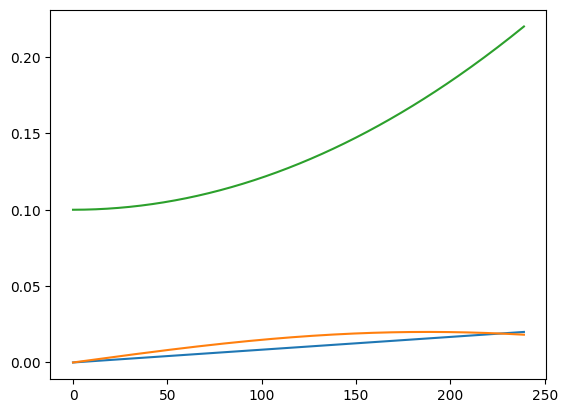

In [9]:
plt.plot(np.c_[0.01 * times, 0.02 * np.sin(times), 0.1 + 0.03 * times**2])

## 8. Spatial Smoothness Analytic Versus Finite Difference

For consecutive calibration nodes $X_m,X_{m+1}\in\mathrm{SE}(3)$,

$$
r_m=
\operatorname{Log}\!\left(X_m^{-1}X_{m+1}\right).
$$

Under left perturbations $X_i'=\operatorname{Exp}(\delta\xi_i)X_i$, the
Jacobian blocks are

$$
\frac{\partial r_m}{\partial\delta\xi_m}
=
-J_l^{-1}(r_m)\operatorname{Ad}_{X_m^{-1}},
\qquad
\frac{\partial r_m}{\partial\delta\xi_{m+1}}
=
J_l^{-1}(r_m)\operatorname{Ad}_{X_m^{-1}}.
$$

Equivalently,

$$
H_m^{\mathrm{smooth}}
=
J_l^{-1}(r_m)\operatorname{Ad}_{X_m^{-1}}
\begin{bmatrix}
-I & I
\end{bmatrix}.
$$

In [10]:
X0 = se3_exp(np.array([0.05, -0.02, 0.03, 0.2, -0.1, 0.3]))
X1 = se3_exp(np.array([0.06, -0.01, 0.035, 0.22, -0.09, 0.32]))
sm = spatial_smoothness_jacobians_left(X0, X1)
H0 = finite_difference_left_jacobian_se3(lambda X: spatial_smoothness_residual(X, X1), X0, 1e-2)
H1 = finite_difference_left_jacobian_se3(lambda X: spatial_smoothness_residual(X0, X), X1, 1e-2)
record("smooth H_X_m", sm.H_X_m, H0, atol=2e-6)
record("smooth H_X_m1", sm.H_X_m1, H1, atol=2e-6)

(1.941503485758389e-10, 1.9403286215148023e-10)

## 9. Extrinsic-Prior Analytic Versus Finite Difference

For a nominal anchor $X_0$ and current calibration $X$,

$$
r^{\mathrm{prior}}
=
\operatorname{Log}\!\left(X^{-1}X_0\right).
$$

With the left perturbation $X'=\operatorname{Exp}(\delta\xi)X$, the checked
Jacobian is

$$
\frac{\partial r^{\mathrm{prior}}}{\partial\delta\xi}
=
-J_l^{-1}(r^{\mathrm{prior}})
\operatorname{Ad}_{X^{-1}}.
$$

In [11]:
pr = extrinsic_prior_jacobian_left(X0, X1)
Hp = finite_difference_left_jacobian_se3(lambda X: extrinsic_prior_residual(X, X1), X0, 1e-2)
record("prior H_X", pr.H_X, Hp, atol=2e-6)

(1.941505289870804e-10, 1.9403182560936888e-10)

## 10. Conjugation Pose-Residual Calibration Jacobian

The body relative motion and calibration-dependent prediction are

$$
A_m=T_{W B,m}^{-1}T_{W B,m+1},
\qquad
\hat Z_m(X)=X^{-1}A_mX.
$$

Using the prediction-first residual convention,

$$
r_m^{\mathrm{cal}}
=
\operatorname{Log}\!\left(\hat Z_m(X)Z_m^{-1}\right).
$$

For $X'=\operatorname{Exp}(\delta\xi)X$, the analytic block tested against
finite differences is

$$
\frac{\partial r_m^{\mathrm{cal}}}{\partial\delta\xi}
=
J_l^{-1}(r_m^{\mathrm{cal}})
\operatorname{Ad}_{X^{-1}}
\left(\operatorname{Ad}_{A_m}-I\right).
$$

In [12]:
T0 = se3_exp(np.array([0.02, -0.01, 0.03, 0.1, 0.0, 0.0]))
T1 = se3_exp(np.array([0.04, -0.015, 0.08, 0.5, 0.2, 0.05]))
X = se3_exp(np.array([0.01, 0.02, -0.02, 0.3, -0.1, 0.2]))
Z_true = sensor_relative_prediction(T0, T1, X)
Z = se3_exp(np.array([1e-4, -2e-4, 1.5e-4, 3e-4, -1e-4, 2e-4])*1e2) @ Z_true
cal = pose_residual_calibration_jacobian_left(T0, T1, X, Z)
Hfd = finite_difference_left_jacobian_se3(
    lambda Y: relative_pose_residual_prediction_first(sensor_relative_prediction(T0, T1, Y), Z), X
)
record("pose calibration H_X", cal.H_X, Hfd, atol=5e-6)

(9.97098464905477e-09, 2.1287731027617094e-08)

## 11. Whitening Validation

Let $\Sigma=L_\Sigma L_\Sigma^\top$ be the residual covariance Cholesky
factorization. The implementation whitens by triangular solves:

$$
\bar r=L_\Sigma^{-1}r,
\qquad
\bar H=L_\Sigma^{-1}H.
$$

The quadratic form is preserved as

$$
\bar r^\top\bar r
=
r^\top\Sigma^{-1}r.
$$

In [13]:
r = np.array([0.3, -0.2, 0.1])
H = rng.normal(size=(3, 5))
Sigma = np.array([[2.0, 0.2, 0.1], [0.2, 1.5, 0.0], [0.1, 0.0, 1.0]])
rb, Hb = whiten_residual_and_jacobian_dense(r, H, Sigma)
assert np.allclose(rb @ rb, r @ np.linalg.inv(Sigma) @ r, atol=1e-12)

## 12. Parameter-Scaling Validation

Parameter scaling uses characteristic units through

$$
\delta x=D\,\delta y,
\qquad
J_{\mathrm{scaled}}=JD,
$$

where $D$ is diagonal over rotation, translation, bias, and temporal-offset
blocks. If $D$ is nonsingular, then

$$
\operatorname{rank}(JD)=\operatorname{rank}(J).
$$

In [14]:
layout = VariableLayout.from_specs([("T_W_B_0", 6, "trajectory"), ("T_B_L", 6, "calibration"), ("b_g", 3, "calibration"), ("tau_L", 1, "calibration")])
scales = ParameterScales(rotation_scale_rad=0.1, translation_scale_m=2.0, gyro_bias_scale_rad_s=0.01, time_offset_scale_s=0.05)
Dd = build_parameter_scaling_dense(layout.blocks, scales)
Ds = build_parameter_scaling_sparse(layout.blocks, scales)
J = rng.normal(size=(12, layout.total_dim))
record("dense sparse scaling", scale_jacobian_dense(J, Dd), scale_jacobian_sparse(sparse.csr_matrix(J), Ds).toarray(), atol=1e-12)
assert np.linalg.matrix_rank(J) == np.linalg.matrix_rank(scale_jacobian_dense(J, Dd))

## 13. Gram-Matrix And Null-Space Examples

For a Jacobian-like matrix $J$, the Gram matrix and null space are

$$
G=J^\top J,
\qquad
\mathcal{N}(J)=\{z:Jz=0\}.
$$

With singular values $\sigma_i(J)$ and tolerance $\epsilon$,

$$
\operatorname{rank}(J)
=
\#\{i:\sigma_i(J)>\epsilon\},
\qquad
\dim\mathcal{N}(J)=n-\operatorname{rank}(J).
$$

In [15]:
M = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])
G = gram_matrix_dense(M)
ns = null_space_dense(M, tolerance=1e-12)
assert G.shape == (3, 3)
assert ns.shape[1] == 1
assert np.allclose(M @ ns, 0.0, atol=1e-12)

## 14. Tiny 2D Geometric Projector Example

The trajectory-column projector and its orthogonal complement are

$$
P_T=J_TJ_T^\dagger,
\qquad
P_T^\perp=I-J_TJ_T^\dagger.
$$

The effective calibration observability matrix is

$$
\mathcal{O}_C=P_T^\perp J_C.
$$

For the toy example,

$$
J_T=
\begin{bmatrix}
1\\0
\end{bmatrix},
\quad
J_C=I_2
\quad\Rightarrow\quad
\mathcal{O}_C=
\begin{bmatrix}
0&0\\0&1
\end{bmatrix}.
$$

In [16]:
J_T = np.array([[1.0], [0.0]])
J_C = np.eye(2)
O = effective_observability_dense(J_T, J_C)
assert np.allclose(O, np.array([[0.0, 0.0], [0.0, 1.0]]))

## 15. Dense Explicit Projector Versus Dense QR Projection

If a complete QR factorization separates the trajectory column space as

$$
J_T=Q_1R,
\qquad
Q=[Q_1\;Q_2],
\qquad
Q_2Q_2^\top=P_T^\perp,
$$

then the reduced QR observability matrix

$$
\widetilde{\mathcal{O}}_C=Q_2^\top J_C
$$

has the same reduced information as the explicit projection:

$$
\widetilde{\mathcal{O}}_C^\top\widetilde{\mathcal{O}}_C
=
J_C^\top P_T^\perp J_C
=
\mathcal{O}_C^\top\mathcal{O}_C.
$$

In [17]:
J_T = rng.normal(size=(45, 8))
J_C = rng.normal(size=(45, 5))
O = effective_observability_dense(J_T, J_C)
Oq = effective_observability_dense_qr(J_T, J_C)
record("dense projector vs QR S", O.T @ O, Oq.T @ Oq, atol=1e-9)

(1.4210854715202004e-14, 3.3537694259526323e-16)

## 16. Dense Projection Versus Sparse LSMR Projection

For each calibration column $c_j$, sparse projection solves

$$
x_j^\star=\arg\min_x\|J_Tx-c_j\|_2,
\qquad
o_j=c_j-J_Tx_j^\star.
$$

The sparse result stacks $O_C=[o_1,\ldots,o_{n_C}]$ and forms

$$
S_C=O_C^\top O_C,
$$

which is compared with the dense projected information.

In [18]:
sp_result = effective_observability_sparse_lsmr(sparse.csr_matrix(J_T), sparse.csr_matrix(J_C))
record("dense vs sparse LSMR S", O.T @ O, sp_result.S_C, atol=1e-8)

(1.4210854715202004e-14, 2.1843310451310168e-16)

## 17. Dense Schur Complement Versus Projected Information

For the partitioned Jacobian $J=[J_T\;J_C]$, define

$$
A=J_T^\top J_T,
\qquad
B=J_T^\top J_C,
\qquad
C=J_C^\top J_C.
$$

When $J_T$ has full column rank, the reduced calibration information is

$$
S_C=C-B^\top A^{-1}B
=
J_C^\top
\left[
I-J_T(J_T^\top J_T)^{-1}J_T^\top
\right]
J_C.
$$

In [19]:
S_proj = O.T @ O
S_schur = schur_complement_dense(J_T, J_C)
record("Schur vs projection", S_schur, S_proj, atol=1e-9)

(1.4210854715202004e-14, 2.43260033219951e-16)

## 18. Verification: `S_C == O_C.T @ O_C`

With

$$
\mathcal{O}_C=P_T^\perp J_C,
\qquad
(P_T^\perp)^\top=P_T^\perp,
\qquad
(P_T^\perp)^2=P_T^\perp,
$$

the reduced information satisfies

$$
S_C
=
J_C^\top P_T^\perp J_C
=
\mathcal{O}_C^\top\mathcal{O}_C.
$$

In [20]:
S_C = reduced_information_dense(O)
record("S_C identity", S_C, O.T @ O, atol=1e-12)

(0.0, 0.0)

## 19. Random Sparse Block-Jacobian Assembly

The global perturbation vector is assembled by variable blocks,

$$
\delta x=
\begin{bmatrix}
\delta x_T\\
\delta x_C
\end{bmatrix},
\qquad
J=
\begin{bmatrix}
J_T & J_C
\end{bmatrix}.
$$

Each local block $H_{ij}$ is inserted into its residual rows and variable
columns:

$$
J[\mathcal{R}_i,\mathcal{C}_j]\leftarrow
J[\mathcal{R}_i,\mathcal{C}_j]+H_{ij}.
$$

In [21]:
layout = VariableLayout.from_specs([("T_W_B_0", 6, "trajectory"), ("T_W_B_1", 6, "trajectory"), ("T_B_L", 6, "calibration")])
residual_blocks = make_residual_blocks([("r0", 6, np.eye(6), "measurement"), ("r1", 6, np.eye(6), "measurement")])
blocks = [
    JacobianBlock("r0", "T_W_B_0", rng.normal(size=(6, 6))),
    JacobianBlock("r0", "T_B_L", rng.normal(size=(6, 6))),
    JacobianBlock("r1", "T_W_B_1", rng.normal(size=(6, 6))),
    JacobianBlock("r1", "T_B_L", rng.normal(size=(6, 6))),
]
bd = assemble_jacobian_dense(layout, residual_blocks, blocks)
bs = assemble_jacobian_sparse(layout, residual_blocks, blocks)
record("dense sparse assembly J", bd.J, bs.J.toarray(), atol=1e-12)
save_sparsity_plot(bs.J, OUT / "random_sparse_jacobian.png", "Random sparse block Jacobian")

PosixPath('/home/camel/Skoltech/phd_proposal/outputs/math_validation/random_sparse_jacobian.png')

## 20. Dense Versus Sparse Results

The dense and sparse assemblies represent the same partitioned linearization,
so their reduced calibration information should agree:

$$
\mathcal{O}_{C,d}=P_T^\perp J_C,
\qquad
\mathcal{O}_{C,s}
=
\left[
c_j-J_T\arg\min_x\|J_Tx-c_j\|_2
\right]_{j=1}^{n_C},
$$

$$
\mathcal{O}_{C,d}^\top\mathcal{O}_{C,d}
\approx
\mathcal{O}_{C,s}^\top\mathcal{O}_{C,s}.
$$

In [22]:
Od = effective_observability_dense(bd.J_T, bd.J_C)
Os = effective_observability_sparse_lsmr(bs.J_T, bs.J_C)
record("assembled dense sparse S", Od.T @ Od, Os.S_C, atol=1e-8)

(1.286324769958184e-25, 2.6835777336723057e-10)

## 21. Runtime And Memory Comparison

For a dense matrix with $m$ rows and $n$ columns, storage scales as

$$
\mathrm{bytes}_{\mathrm{dense}}\approx 8mn.
$$

For CSR sparse storage,

$$
\mathrm{bytes}_{\mathrm{csr}}
=
\mathrm{bytes}(\mathrm{data})
+\mathrm{bytes}(\mathrm{indices})
+\mathrm{bytes}(\mathrm{indptr}),
$$

and sparse projection avoids explicitly forming the dense residual-space
projector $P_T^\perp\in\mathbb{R}^{m\times m}$.

In [23]:
big_T = sparse.random(250, 70, density=0.035, random_state=1, format="csr")
big_C = sparse.random(250, 8, density=0.2, random_state=2, format="csr")
t0 = time.perf_counter()
sparse_big = effective_observability_sparse_lsmr(big_T, big_C)
sparse_runtime = time.perf_counter() - t0
dense_nbytes = big_T.toarray().nbytes + big_C.toarray().nbytes
sparse_nbytes = big_T.data.nbytes + big_T.indices.nbytes + big_T.indptr.nbytes + big_C.data.nbytes + big_C.indices.nbytes + big_C.indptr.nbytes
assert sparse_big.S_C.shape == (8, 8)
print({"sparse_runtime_s": sparse_runtime, "dense_nbytes": dense_nbytes, "sparse_nbytes": sparse_nbytes})

{'sparse_runtime_s': 0.06331721693277359, 'dense_nbytes': 156000, 'sparse_nbytes': 14164}


## 22. Motion-Only `C_X` Rank Test

For fixed body motions $A_m$, the motion-only spatial calibration sensitivity
matrix is

$$
\mathcal{C}_X=
\begin{bmatrix}
\operatorname{Ad}_{A_0}-I\\
\operatorname{Ad}_{A_1}-I\\
\vdots\\
\operatorname{Ad}_{A_{N-1}}-I
\end{bmatrix}.
$$

After whitening and left-Jacobian factors, the fixed-trajectory Jacobian can be
written as

$$
\bar J_X=B\mathcal{C}_X.
$$

If $B$ is invertible, then

$$
\operatorname{rank}(\bar J_X)=\operatorname{rank}(\mathcal{C}_X),
\qquad
\mathcal{N}(\bar J_X)=\mathcal{N}(\mathcal{C}_X),
$$

although singular values are generally not preserved.

In [24]:
A_list = [
    se3_exp(np.array([0.0, 0.0, 0.3, 1.0, 0.0, 0.0])),
    se3_exp(np.array([0.2, 0.1, 0.0, 0.0, 1.0, 0.2])),
    se3_exp(np.array([-0.1, 0.3, 0.2, 0.4, -0.2, 1.0])),
]
C_X = build_motion_only_matrix_dense(A_list)
assert numerical_rank_dense(C_X, tolerance=1e-9) == 6
B = sparse.block_diag([rng.normal(size=(6, 6)) + 4.0 * np.eye(6) for _ in A_list]).toarray()
# (18,6) = (18,18) x (18,6)
BC = B @ C_X
assert numerical_rank_dense(BC, tolerance=1e-9) == numerical_rank_dense(C_X, tolerance=1e-9)
assert not np.allclose(np.linalg.svd(BC, compute_uv=False), np.linalg.svd(C_X, compute_uv=False))
save_singular_values_plot(np.linalg.svd(C_X, compute_uv=False), OUT / "motion_only_singular_values.png", "C_X singular values")

PosixPath('/home/camel/Skoltech/phd_proposal/outputs/math_validation/motion_only_singular_values.png')

## 23. Full-Rank `C_X` But Jointly Deficient Example

For one calibration variable $X$, the joint observability matrix removes all
changes reproducible by nuisance variables:

$$
\mathcal{O}_X
=
\left(I-J_NJ_N^\dagger\right)J_X.
$$

If $J_X=J_NK$ for some matrix $K$, then

$$
\mathcal{O}_X
=
\left(I-J_NJ_N^\dagger\right)J_NK
=0.
$$

Thus $J_X$ can be full rank when the trajectory is fixed, while $X$ is jointly
unobservable after nuisance compensation.

In [25]:
J_X = C_X.copy()
J_N = J_X.copy()
O_X = effective_observability_dense(J_N, J_X)
assert numerical_rank_dense(J_X, tolerance=1e-9) == 6
assert numerical_rank_dense(O_X, tolerance=1e-9) == 0

## 24. Summary Table Of Numerical Errors

The final cell reports every recorded comparison and enforces the aggregate
accuracy check

$$
\max_i e_{\infty,i}<10^{-5}.
$$

In [26]:
for name, max_abs, rel in errors:
    print(f"{name:35s} max_abs={max_abs:.3e} rel={rel:.3e}")
assert max(e[1] for e in errors) < 1e-5

SO3 Log(Exp)                        max_abs=1.110e-16 rel=1.905e-16
SO3 Exp(Log)                        max_abs=1.110e-16 rel=1.241e-16
SO3 Log(Exp)                        max_abs=2.498e-16 rel=6.468e-16
SO3 Exp(Log)                        max_abs=2.429e-16 rel=2.018e-16
SO3 Log(Exp)                        max_abs=5.551e-17 rel=1.829e-16
SO3 Exp(Log)                        max_abs=1.110e-16 rel=8.012e-17
SO3 Log(Exp)                        max_abs=1.110e-16 rel=2.108e-16
SO3 Exp(Log)                        max_abs=1.110e-16 rel=9.480e-17
SO3 Log(Exp)                        max_abs=5.551e-17 rel=1.404e-16
SO3 Exp(Log)                        max_abs=5.551e-17 rel=7.166e-17
SO3 Log(Exp)                        max_abs=1.110e-16 rel=1.968e-16
SO3 Exp(Log)                        max_abs=1.110e-16 rel=1.329e-16
SO3 Log(Exp)                        max_abs=1.388e-17 rel=1.758e-17
SO3 Exp(Log)                        max_abs=1.388e-17 rel=8.012e-18
SO3 Log(Exp)                        max_abs=1.11

## Analytic Jacobian Validation Appendix

The following appended sections validate the analytic IMU and LiDAR factor linearizations against central finite differences. All checks use left perturbations, rotation-first SE(3) tangents, and prediction-first LiDAR residuals.

In [27]:
from pathlib import Path
import sys, time
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))
ANALYTIC_OUT = ROOT / "outputs" / "math_validation" / "analytic_jacobians"
ANALYTIC_OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from calib_observability.backend import estimate_poses_dummy
from calib_observability.interpolation import interpolate_so3, interpolate_so3_with_angular_velocity, interpolate_se3, interpolate_se3_with_twist
from calib_observability.jacobians import *
from calib_observability.lie_so3 import so3_exp, so3_log
from calib_observability.lie_se3 import se3_adjoint, se3_exp, se3_inverse, se3_log
from calib_observability.observability import effective_observability_dense, reduced_information_dense
from calib_observability.simulation import PlanarRoverConfig, simulate_planar_rover
from calib_observability.types import JacobianOptions, validate_jacobian_method

validation_rng = np.random.default_rng(2026)
CHECK_RESULTS = []


## 21. SO(3) geodesic interpolation

Formula: `R(alpha) = R_0 Exp(alpha Log(R_0^{-1} R_1))`. Finite differences perturb time inside the segment and check that the returned body angular velocity matches the local geodesic derivative. Expected dimensions are rotations `(3,3)` and angular velocities `(3,)`.

In [28]:
R0 = so3_exp(np.array([0.1, -0.05, 0.02]))
R1 = R0 @ so3_exp(np.array([0.2, 0.1, -0.04]))
assert np.allclose(interpolate_so3(R0, R1, 0.0), R0)
assert np.allclose(interpolate_so3(R0, R1, 1.0), R1)
Rt, omega_body, omega_spatial = interpolate_so3_with_angular_velocity(R0, R1, 1.0, 3.0, 1.7)
assert np.allclose(Rt.T @ Rt, np.eye(3), atol=1e-10)
assert np.allclose(omega_spatial, Rt @ omega_body)
dt = 1e-6
omega_fd = so3_log(interpolate_so3_with_angular_velocity(R0, R1, 1.0, 3.0, 1.7-dt)[0].T @ interpolate_so3_with_angular_velocity(R0, R1, 1.0, 3.0, 1.7+dt)[0]) / (2*dt)
assert np.allclose(omega_fd, omega_body, atol=1e-6)
print({"omega_body": omega_body, "omega_spatial": omega_spatial})


{'omega_body': array([ 0.1 ,  0.05, -0.02]), 'omega_spatial': array([ 0.09971031,  0.05349194, -0.0098217 ])}


## 22. SE(3) geodesic interpolation

Formula: `T(alpha) = T_0 Exp(alpha Log(T_0^{-1} T_1))`. The body twist is `xi/(t_1-t_0)` and the spatial twist is `Adj(T_t) xi_body`. The test point is deliberately inside the interval, not at a knot.

In [29]:
T0 = se3_exp(np.array([0.1, -0.05, 0.02, 0.2, -0.1, 0.05]))
T1 = T0 @ se3_exp(np.array([0.15, 0.08, -0.04, 0.3, 0.2, -0.1]))
assert np.allclose(interpolate_se3(T0, T1, 0.0), T0)
assert np.allclose(interpolate_se3(T0, T1, 1.0), T1)
Tt, xi_body, xi_spatial = interpolate_se3_with_twist(T0, T1, 1.0, 3.0, 1.7)
assert np.allclose(xi_spatial, se3_adjoint(Tt) @ xi_body)
xi_fd = se3_log(se3_inverse(interpolate_se3_with_twist(T0, T1, 1.0, 3.0, 1.7-dt)[0]) @ interpolate_se3_with_twist(T0, T1, 1.0, 3.0, 1.7+dt)[0]) / (2*dt)
assert np.allclose(xi_fd, xi_body, atol=1e-6)
print({"xi_body": xi_body, "xi_spatial": xi_spatial})


{'xi_body': array([ 0.075,  0.04 , -0.02 ,  0.15 ,  0.1  , -0.05 ]), 'xi_spatial': array([ 0.07497107,  0.04310739, -0.01208685,  0.14904225,  0.11327513,
       -0.01598001])}


## 23-29. IMU factor residual anatomy and analytic Jacobians

The gyroscope factor uses `E_I = R_k C Exp(phi) C^{-1} R_k1^{-1}`, `r_I = Log(E_I)`, and `phi = integral(omega(s)-b_g) ds`. The code below prints the residual anatomy, compares each analytic block with finite differences, asserts that `T_B_I` translation columns are zero for the analytic gyro-only residual, and builds the complete `(3,22)` local matrix.

{'phi': array([-6.19775749e-05, -4.17441494e-05, -2.56815937e-05]), 'Delta_R': array([[ 9.99999999e-01,  2.56828873e-05, -4.17433535e-05],
       [-2.56803001e-05,  9.99999998e-01,  6.19781109e-05],
       [ 4.17449451e-05, -6.19770389e-05,  9.99999997e-01]]), 'C': array([[ 0.99935008, -0.03009299, -0.01984535],
       [ 0.02989301,  0.99950006, -0.01029763],
       [ 0.02014532,  0.0096977 ,  0.99975003]]), 'Q': array([[ 9.99999999e-01,  2.73298573e-05, -4.33106943e-05],
       [-2.73272511e-05,  9.99999998e-01,  6.01720195e-05],
       [ 4.33123387e-05, -6.01708359e-05,  9.99999997e-01]]), 'E_I': array([[ 9.99999999e-01,  2.73298573e-05, -4.33106943e-05],
       [-2.73272511e-05,  9.99999998e-01,  6.01720195e-05],
       [ 4.33123387e-05, -6.01708359e-05,  9.99999997e-01]]), 'r_I': array([-6.01714278e-05, -4.33115165e-05, -2.73285542e-05])}
T_start (3, 6) 8.065895080936993e-10 5.252466777164614e-10
T_end (3, 6) 1.970892965626894e-09 1.160650824891321e-09
T_B_I (3, 6) 1.29995653298927

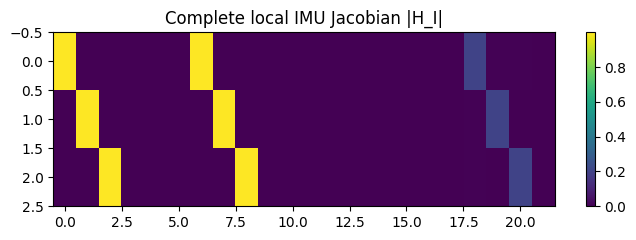

In [30]:
cfg = PlanarRoverConfig(imu_rate_hz=100.0, lidar_rate_hz=5.0, total_laps=1, random_seed=71)
ds = simulate_planar_rover(cfg, mode="one_rectangle")
provider = estimate_poses_dummy(ds)
measurement_index = 5
t0 = float(ds.lidar.relative_start_times[measurement_index] + ds.tau_L_true)
t1 = float(ds.lidar.relative_end_times[measurement_index] + ds.tau_L_true)
poses = provider.poses_at(np.array([t0, t1]))
imu_a = linearize_gyro_factor_analytic(poses[0], poses[1], ds.T_B_I_true, ds.gyro_bias_true, ds.tau_I_true, t0, t1, ds.imu.sensor_timestamps, ds.imu.gyroscope)
imu_f = linearize_gyro_factor_finite_difference(poses[0], poses[1], ds.T_B_I_true, ds.gyro_bias_true, ds.tau_I_true, t0, t1, ds.imu.sensor_timestamps, ds.imu.gyroscope)
terms = imu_a.intermediate_terms
print({"phi": terms.phi, "Delta_R": terms.Delta_R, "C": terms.C, "Q": terms.Q, "E_I": terms.E_I, "r_I": terms.residual})
assert np.allclose(so3_exp(so3_log(terms.E_I)), terms.E_I, atol=1e-10)
imu_blocks = {
    "T_start": (imu_a.H_start_pose, imu_f.H_start_pose),
    "T_end": (imu_a.H_end_pose, imu_f.H_end_pose),
    "T_B_I": (imu_a.H_T_B_I, imu_f.H_T_B_I),
    "b_g": (imu_a.H_b_g, imu_f.H_b_g),
    "tau_I": (imu_a.H_tau_I, imu_f.H_tau_I),
}
for name, (Ha, Hf) in imu_blocks.items():
    max_abs = float(np.max(np.abs(Ha - Hf)))
    rel = float(np.linalg.norm(Ha-Hf) / max(np.linalg.norm(Hf), np.finfo(float).eps))
    print(name, Ha.shape, max_abs, rel)
    assert np.allclose(Ha, Hf, atol=1e-6, rtol=1e-5)
assert np.array_equal(imu_a.H_T_B_I[:, 3:6], np.zeros((3, 3)))
assert np.allclose(imu_f.H_T_B_I[:, 3:6], 0.0, atol=1e-7)
H_I = np.hstack([imu_a.H_start_pose, imu_a.H_end_pose, imu_a.H_T_B_I, imu_a.H_b_g, imu_a.H_tau_I])
H_I_fd = np.hstack([imu_f.H_start_pose, imu_f.H_end_pose, imu_f.H_T_B_I, imu_f.H_b_g, imu_f.H_tau_I])
assert H_I.shape == (3, 22)
assert np.allclose(H_I, H_I_fd, atol=1e-6, rtol=1e-5)
fig, ax = plt.subplots(figsize=(7, 2.5)); im = ax.imshow(np.abs(H_I), aspect="auto"); ax.set_title("Complete local IMU Jacobian |H_I|"); fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig(ANALYTIC_OUT / "imu_local_jacobian_heatmap.png", dpi=160); plt.show(); plt.close(fig)


## 30-35. LiDAR factor residual anatomy and analytic Jacobians

The LiDAR residual is prediction-first: `r_L = Log(Z_hat @ inverse(Z_measurement))`, with `Z_hat = inverse(X_L) inverse(T_0) T_1 X_L`. The temporal-offset block is checked with both spatial- and body-twist formulas and scalar central differences. The complete local matrix has shape `(6,19)`.

In [31]:
linearize_lidar_factor_analytic?

Signature:
linearize_lidar_factor_analytic(
    start_body_pose: 'ArrayLike',
    end_body_pose: 'ArrayLike',
    body_from_lidar: 'ArrayLike',
    lidar_measurement: 'ArrayLike',
    start_spatial_twist: 'ArrayLike',
    end_spatial_twist: 'ArrayLike',
) -> 'LidarFactorLinearization'
Docstring: Compute all analytic LiDAR factor blocks with prediction-first residuals.
File:      ~/Skoltech/phd_proposal/src/calib_observability/jacobians.py
Type:      function

{'A': array([[ 9.95617727e-01, -9.35118780e-02,  9.32452805e-04,
         1.77542078e-01],
       [ 9.35164841e-02,  9.95577318e-01, -8.97057026e-03,
         2.60838517e-01],
       [-8.94739906e-05,  9.01845849e-03,  9.99959329e-01,
         1.21541125e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]), 'Z_hat': array([[ 9.95617847e-01, -9.35135001e-02,  5.72979810e-04,
         1.82341932e-01],
       [ 9.35148621e-02,  9.95577199e-01, -9.00068293e-03,
         2.85074854e-01],
       [ 2.71239729e-04,  9.01482269e-03,  9.99959329e-01,
         1.22018950e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]), 'Z_measurement': array([[ 9.95339707e-01, -9.64295858e-02,  4.50505068e-04,
         1.47788956e-01],
       [ 9.64306166e-02,  9.95331741e-01, -3.98266171e-03,
         2.58175573e-01],
       [-6.43555752e-05,  4.00754382e-03,  9.99991968e-01,
         1.01525901e-01],
       [ 0.00000000e+00,  0.0

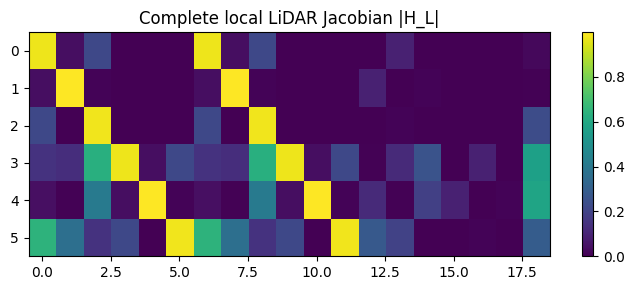

In [32]:
ds_l = simulate_planar_rover(cfg, mode="multi-axis_3d_reference_motion")
provider_l = estimate_poses_dummy(ds_l)
measurement_index = 0
query_times = np.array([ds_l.lidar.relative_start_times[measurement_index] + ds_l.tau_L_true, ds_l.lidar.relative_end_times[measurement_index] + ds_l.tau_L_true])
poses_l, body_twists_l, spatial_twists_l = provider_l.poses_and_twists_at(query_times)
lid_a = linearize_lidar_factor_analytic(poses_l[0], poses_l[1], ds_l.T_B_L_true, ds_l.lidar.measurements[measurement_index], spatial_twists_l[0], spatial_twists_l[1])
lid_f = linearize_lidar_factor_finite_difference(poses_l[0], poses_l[1], ds_l.T_B_L_true, ds_l.lidar.measurements[measurement_index], provider_l, float(ds_l.lidar.relative_start_times[measurement_index]), float(ds_l.lidar.relative_end_times[measurement_index]), ds_l.tau_L_true)
lt = lid_a.intermediate_terms
print({"A": lt.A, "Z_hat": lt.Z_hat, "Z_measurement": ds_l.lidar.measurements[measurement_index], "E_L": lt.E_L, "r_L": lt.residual})
assert np.allclose(lid_a.H_end_pose, -lid_a.H_start_pose)
H_tau_body = lidar_factor_temporal_offset_jacobian_body(lt, body_twists_l[0], body_twists_l[1])
assert np.allclose(H_tau_body, lid_a.H_tau_L, atol=1e-5)
lidar_blocks = {
    "T_start": (lid_a.H_start_pose, lid_f.H_start_pose),
    "T_end": (lid_a.H_end_pose, lid_f.H_end_pose),
    "T_B_L": (lid_a.H_T_B_L, lid_f.H_T_B_L),
    "tau_L": (lid_a.H_tau_L, lid_f.H_tau_L),
}
for name, (Ha, Hf) in lidar_blocks.items():
    max_abs = float(np.max(np.abs(Ha - Hf)))
    rel = float(np.linalg.norm(Ha-Hf) / max(np.linalg.norm(Hf), np.finfo(float).eps))
    print(name, Ha.shape, max_abs, rel)
    assert np.allclose(Ha, Hf, atol=1e-5, rtol=1e-5)
print("motion-only block Adj(A)-I", se3_adjoint(lt.A) - np.eye(6))
H_L = np.hstack([lid_a.H_start_pose, lid_a.H_end_pose, lid_a.H_T_B_L, lid_a.H_tau_L])
H_L_fd = np.hstack([lid_f.H_start_pose, lid_f.H_end_pose, lid_f.H_T_B_L, lid_f.H_tau_L])
assert H_L.shape == (6, 19)
assert np.allclose(H_L, H_L_fd, atol=1e-5, rtol=1e-5)
fig, ax = plt.subplots(figsize=(7, 3)); im = ax.imshow(np.abs(H_L), aspect="auto"); ax.set_title("Complete local LiDAR Jacobian |H_L|"); fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig(ANALYTIC_OUT / "lidar_local_jacobian_heatmap.png", dpi=160); plt.show(); plt.close(fig)


## 36-39. Dispatcher, pipeline, runtime, and final summary

The same IMU/LiDAR factors and one full simulation window are evaluated with `analytic`, `finite_difference`, and `analytic_checked`. Analytic is the intended production method; finite differences are the reference; checked mode stores diagnostics and fails loudly on mismatches.

In [33]:
options_analytic = JacobianOptions(method="analytic")
options_fd = JacobianOptions(method="finite_difference")
options_checked = JacobianOptions(method="analytic_checked")
assert validate_jacobian_method("analytic") == "analytic"
try:
    validate_jacobian_method("invalid")
    raise AssertionError("invalid method should fail")
except ValueError:
    pass

imu_checked = linearize_gyro_factor(poses[0], poses[1], ds.T_B_I_true, ds.gyro_bias_true, ds.tau_I_true, t0, t1, ds.imu.sensor_timestamps, ds.imu.gyroscope, jacobian_options=options_checked)
lid_checked = linearize_lidar_factor(poses_l[0], poses_l[1], ds_l.T_B_L_true, ds_l.lidar.measurements[measurement_index], spatial_twists_l[0], spatial_twists_l[1], pose_provider=provider_l, sensor_start_time=float(ds_l.lidar.relative_start_times[measurement_index]), sensor_end_time=float(ds_l.lidar.relative_end_times[measurement_index]), lidar_time_offset=ds_l.tau_L_true, jacobian_options=options_checked)
CHECK_RESULTS.extend(imu_checked.check_results); CHECK_RESULTS.extend(lid_checked.check_results)
assert CHECK_RESULTS and all(result.passed for result in CHECK_RESULTS)

window_start, window_end = 1.0, 3.0
start_time = time.perf_counter(); bundle_a, _, counts_a = ds.window_jacobians(window_start, window_end, provider, use_sparse=False, jacobian_options=options_analytic); runtime_a = time.perf_counter() - start_time
start_time = time.perf_counter(); bundle_fd, _, counts_fd = ds.window_jacobians(window_start, window_end, provider, use_sparse=False, jacobian_options=options_fd); runtime_fd = time.perf_counter() - start_time
start_time = time.perf_counter(); bundle_c, _, counts_c = ds.window_jacobians(window_start, window_end, provider, use_sparse=False, jacobian_options=options_checked); runtime_c = time.perf_counter() - start_time
assert np.allclose(bundle_a.residual, bundle_fd.residual, atol=1e-10)
assert np.allclose(bundle_a.J, bundle_fd.J, atol=2e-4)
O_a = effective_observability_dense(bundle_a.J_T, bundle_a.J_C); O_fd = effective_observability_dense(bundle_fd.J_T, bundle_fd.J_C)
assert np.allclose(O_a, O_fd, atol=3e-4)
S_a = reduced_information_dense(O_a); S_fd = reduced_information_dense(O_fd)
assert np.allclose(S_a, S_fd, atol=1e-2, rtol=1e-5)
print({"analytic_runtime": runtime_a, "finite_difference_runtime": runtime_fd, "analytic_checked_runtime": runtime_c, "shape": bundle_a.J.shape, "counts": counts_a, "max_check_error": bundle_c.metadata["maximum_jacobian_check_error"]})
for result in CHECK_RESULTS:
    print(result.factor_name, result.variable_name, result.analytic_shape, f"max={result.max_absolute_error:.3e}", f"rel={result.relative_frobenius_error:.3e}", result.passed)
assert all(result.passed for result in CHECK_RESULTS)


{'analytic_runtime': 0.05605426011607051, 'finite_difference_runtime': 0.5227558948099613, 'analytic_checked_runtime': 0.5462697139009833, 'shape': (90, 77), 'counts': {'imu': 10, 'lidar': 10}, 'max_check_error': 6.997359200664778e-07}
imu_gyro T_start (3, 6) max=8.066e-10 rel=5.252e-10 True
imu_gyro T_end (3, 6) max=1.971e-09 rel=1.161e-09 True
imu_gyro T_B_I (3, 6) max=1.300e-09 rel=1.542e-05 True
imu_gyro b_g (3, 3) max=4.219e-10 rel=1.417e-09 True
imu_gyro tau_I (3, 1) max=2.537e-08 rel=6.014e-06 True
lidar_relative_pose T_start (6, 6) max=5.941e-07 rel=3.393e-07 True
lidar_relative_pose T_end (6, 6) max=5.942e-07 rel=3.394e-07 True
lidar_relative_pose T_B_L (6, 6) max=4.545e-07 rel=1.886e-06 True
lidar_relative_pose tau_L (6, 1) max=8.172e-07 rel=1.345e-06 True


## Sparse one

In [34]:
from calib_observability.observability import effective_observability_sparse_lsmr

window_start, window_end = 1.0, 3.0

start_time = time.perf_counter()
bundle_a, _, counts_a = ds.window_jacobians(
    window_start,
    window_end,
    provider,
    use_sparse=True,
    jacobian_options=options_analytic,
)
runtime_a = time.perf_counter() - start_time

start_time = time.perf_counter()
bundle_fd, _, counts_fd = ds.window_jacobians(
    window_start,
    window_end,
    provider,
    use_sparse=True,
    jacobian_options=options_fd,
)
runtime_fd = time.perf_counter() - start_time

start_time = time.perf_counter()
bundle_c, _, counts_c = ds.window_jacobians(
    window_start,
    window_end,
    provider,
    use_sparse=True,
    jacobian_options=options_checked,
)
runtime_c = time.perf_counter() - start_time

assert np.allclose(bundle_a.residual, bundle_fd.residual, atol=1e-10)

# Compare sparse global Jacobians by converting only for this small validation window.
assert np.allclose(bundle_a.J.toarray(), bundle_fd.J.toarray(), atol=2e-4)
assert np.allclose(bundle_a.J_T.toarray(), bundle_fd.J_T.toarray(), atol=2e-4)
assert np.allclose(bundle_a.J_C.toarray(), bundle_fd.J_C.toarray(), atol=2e-4)

projection_a = effective_observability_sparse_lsmr(bundle_a.J_T, bundle_a.J_C)
projection_fd = effective_observability_sparse_lsmr(bundle_fd.J_T, bundle_fd.J_C)

O_a = projection_a.O_C.toarray()
O_fd = projection_fd.O_C.toarray()

assert np.allclose(O_a, O_fd, atol=3e-4)

S_a = projection_a.S_C
S_fd = projection_fd.S_C
assert np.allclose(S_a, S_fd, atol=1e-2, rtol=1e-5)

print({
    "analytic_runtime": runtime_a,
    "finite_difference_runtime": runtime_fd,
    "analytic_checked_runtime": runtime_c,
    "shape": bundle_a.J.shape,
    "counts": counts_a,
    "sparse_projection_runtime": projection_a.runtime_s,
    "sparse_projection_nnz": projection_a.nnz,
    "max_check_error": bundle_c.metadata["maximum_jacobian_check_error"],
})

for result in CHECK_RESULTS:
    print(
        result.factor_name,
        result.variable_name,
        result.analytic_shape,
        f"max={result.max_absolute_error:.3e}",
        f"rel={result.relative_frobenius_error:.3e}",
        result.passed,
    )

assert all(result.passed for result in CHECK_RESULTS)

{'analytic_runtime': 0.057454150868579745, 'finite_difference_runtime': 0.5394646618515253, 'analytic_checked_runtime': 0.5243006169330329, 'shape': (90, 77), 'counts': {'imu': 10, 'lidar': 10}, 'sparse_projection_runtime': 0.12772162398323417, 'sparse_projection_nnz': 720, 'max_check_error': 6.997359200664778e-07}
imu_gyro T_start (3, 6) max=8.066e-10 rel=5.252e-10 True
imu_gyro T_end (3, 6) max=1.971e-09 rel=1.161e-09 True
imu_gyro T_B_I (3, 6) max=1.300e-09 rel=1.542e-05 True
imu_gyro b_g (3, 3) max=4.219e-10 rel=1.417e-09 True
imu_gyro tau_I (3, 1) max=2.537e-08 rel=6.014e-06 True
lidar_relative_pose T_start (6, 6) max=5.941e-07 rel=3.393e-07 True
lidar_relative_pose T_end (6, 6) max=5.942e-07 rel=3.394e-07 True
lidar_relative_pose T_B_L (6, 6) max=4.545e-07 rel=1.886e-06 True
lidar_relative_pose tau_L (6, 1) max=8.172e-07 rel=1.345e-06 True


## Accelerometer Factor Validation

This section checks the optional accelerometer factors. Measurements are IMU-frame specific force including gravity, `f_m^I = R_IW(a_I^W - g_W) + noise`. The simple residual is gravity-only, `r_g = C^T(-R^T g_W) - f_m^I`, with one `(3,6)` pose block, one `(3,6)` `T_B_I` block, and one `(3,1)` `tau_I` block. The complex residual uses three poses and includes body-origin acceleration, angular velocity, angular acceleration, tangential lever-arm acceleration, and centripetal lever-arm acceleration. All perturbations are left perturbations in rotation-first tangent ordering. A failure means a sign, frame, stencil, or sparse/dense assembly convention has drifted.


In [38]:
from calib_observability.accelerometer import (
    complex_accelerometer_terms,
    linearize_complex_accelerometer_factor,
    linearize_simple_accelerometer_factor,
)
from calib_observability.factor_observability import (
    build_accelerometer_motion_sensitivity,
    effective_target_observability_from_bundle_dense,
    effective_target_observability_from_bundle_sparse,
)
from calib_observability.simulation import reframe_dataset_to_fixed_extrinsic
from calib_observability.types import AccelerometerOptions

accel_cfg = PlanarRoverConfig(
    rectangle_width=2.0,
    rectangle_height=1.0,
    straight_speed=1.0,
    turn_duration=0.5,
    imu_rate_hz=100.0,
    lidar_rate_hz=5.0,
    gyro_noise_std=1e-6,
    accel_noise_std=1e-6,
    random_seed=52,
)
accel_ds = reframe_dataset_to_fixed_extrinsic(simulate_planar_rover(accel_cfg, mode="one_rectangle"), "T_B_L")
accel_provider = estimate_poses_dummy(accel_ds)
print(accel_ds.imu.accelerometer_convention)
print("stationary-like force norm example", np.linalg.norm(accel_ds.imu.accelerometer[0]), "gravity", np.linalg.norm(accel_ds.imu.gravity_world))


specific_force_imu_frame_R_IW_times_a_minus_g
stationary-like force norm example 9.80999904203468 gravity 9.81


### Simple-Mode Analytic Checks

The simple factor uses a single central pose at `t_k = s_k + tau_I`. Its pose and `T_B_I` translation columns must be exactly zero because translation and lever-arm acceleration are not modeled. The finite-difference reference perturbs the same pose/extrinsic with the package left perturbation and shifts the trajectory query for `tau_I`. A failure indicates an incorrect gravity sign, left-perturbation sign, or accidental lever-arm sensitivity.


In [49]:
simple_index = 30
simple_sensor_time = float(accel_ds.imu.sensor_timestamps[simple_index])
simple_true_time = simple_sensor_time + accel_ds.tau_I_true
simple_pose = accel_provider.poses_at(np.array([simple_true_time]))[0]
_, _, simple_spatial_twists = accel_provider.poses_and_twists_at(np.array([simple_true_time]))
simple_checked = linearize_simple_accelerometer_factor(
    simple_pose,
    accel_ds.T_B_I_true,
    accel_ds.imu.accelerometer[simple_index],
    accel_ds.imu.gravity_world,
    simple_spatial_twists[0],
    pose_provider=accel_provider,
    sensor_time=simple_sensor_time,
    tau_I=accel_ds.tau_I_true,
    jacobian_options=JacobianOptions(method="analytic_checked"),
)
for result in simple_checked.check_results:
    print(result.variable_name, result.analytic_shape, f"max={result.max_absolute_error:.3e}", f"rel={result.relative_frobenius_error:.3e}", result.passed)
assert all(result.passed for result in simple_checked.check_results)
assert np.allclose(simple_checked.pose_blocks[0].matrix[:, 3:6], 0.0)
assert np.allclose(simple_checked.H_T_B_I[:, 3:6], 0.0)
print("simple residual", simple_checked.residual)
print("simple H_T_B_I rotation block", simple_checked.H_T_B_I[:, :3])
print("simple H_T_B_I translation block", simple_checked.H_T_B_I[:, 3:6])


T_zero (3, 6) max=6.823e-09 rel=6.569e-10 True
T_B_I (3, 6) max=8.033e-09 rel=6.501e-10 True
tau_I (3, 1) max=0.000e+00 rel=0.000e+00 True
simple residual [ 1.58819824e-06 -5.27122199e-07  8.12325416e-07]
simple H_T_B_I rotation block [[-0.09902453 -9.80750928  0.        ]
 [ 9.80905788 -0.09712316  0.        ]
 [-0.09315372  0.19856688  0.        ]]
simple H_T_B_I translation block [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### Complex-Mode Analytic Checks

The complex factor has support poses `T_-`, `T_0`, and `T_+`, so the pose Jacobian dimensions are three `(3,6)` blocks. The temporal derivative is the full chain rule `H_tau = H_- xi_- + H_0 xi_0 + H_+ xi_+`, where each spatial twist shifts its support time. The finite-difference reference recomputes all three shifted poses and the full specific-force prediction. A failure means one of the discrete acceleration, SO(3) logarithm, lever-arm, or temporal-chain terms is inconsistent.


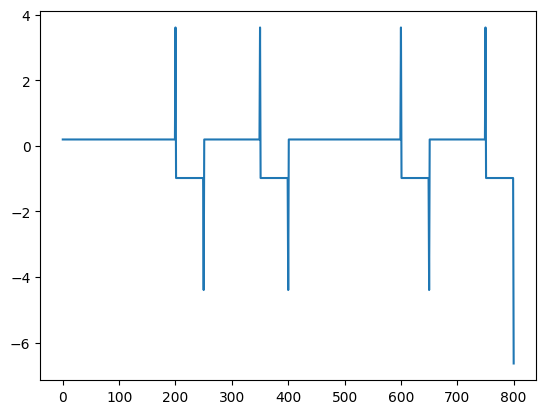

In [59]:
plt.plot(accel_ds.imu.accelerometer[:,0])

In [62]:
complex_h = 0.1
complex_index = 220
complex_sensor_time = float(accel_ds.imu.sensor_timestamps[complex_index])
complex_true_time = complex_sensor_time + accel_ds.tau_I_true
complex_times = np.array([complex_true_time - complex_h, complex_true_time, complex_true_time + complex_h])
complex_poses, _, complex_spatial_twists = accel_provider.poses_and_twists_at(complex_times)
complex_checked = linearize_complex_accelerometer_factor(
    complex_poses[0],
    complex_poses[1],
    complex_poses[2],
    accel_ds.T_B_I_true,
    accel_ds.imu.accelerometer[complex_index],
    accel_ds.imu.gravity_world,
    complex_h,
    complex_spatial_twists[0],
    complex_spatial_twists[1],
    complex_spatial_twists[2],
    pose_provider=accel_provider,
    sensor_time=complex_sensor_time,
    tau_I=accel_ds.tau_I_true,
    jacobian_options=JacobianOptions(method="analytic_checked"),
)
for result in complex_checked.check_results:
    print(result.variable_name, result.analytic_shape, f"max={result.max_absolute_error:.3e}", f"rel={result.relative_frobenius_error:.3e}", result.passed)
assert all(result.passed for result in complex_checked.check_results)
assert np.linalg.matrix_rank(complex_checked.H_T_B_I) <= 3
# print(complex_checked.H_T_B_I[:, 3:5])
assert np.linalg.norm(complex_checked.H_T_B_I[:, 3:5]) > 0.0
assert np.linalg.norm(complex_checked.H_T_B_I[:, 5]) <= 1e-8
print("complex lever-arm block", complex_checked.H_T_B_I[:, 3:6])
print("tau chain block", complex_checked.H_tau_I.ravel())


T_minus (3, 6) max=1.297e-07 rel=6.667e-10 True
T_zero (3, 6) max=2.583e-07 rel=6.073e-10 True
T_plus (3, 6) max=1.297e-07 rel=6.014e-10 True
T_B_I (3, 6) max=9.849e-09 rel=5.422e-10 True
tau_I (3, 1) max=2.539e-07 rel=8.496e-01 True
complex lever-arm block [[-9.86709855  0.09962619  0.        ]
 [-0.09771327 -9.86865656  0.        ]
 [ 0.19977335  0.09371971  0.        ]]
tau chain block [ 1.82665985e-07  3.77575020e-08 -4.04703648e-09]


### Accelerometer Sparse/Dense Assembly Checks

This cell assembles the same fixed-`T_B_L` window with accelerometer simple and complex modes using dense and sparse global Jacobians. The expected dimensions keep `J_C.shape[1] == 11`: `T_B_I(6)`, `b_g(3)`, `tau_I(1)`, and `tau_L(1)`. `C_X_I_accel` is extracted from accelerometer rows and `T_B_I` columns before nuisance projection. A failure indicates the optional accelerometer path has diverged between dense and sparse assembly or accidentally introduced new calibration variables.


In [63]:
for accel_mode in ("simple", "complex"):
    accel_options = AccelerometerOptions(
        mode=accel_mode,
        factor_rate_hz=5.0,
        measurement_std_m_s2=0.05,
        require_low_dynamic_gate=False if accel_mode == "simple" else True,
    )
    dense_bundle, _, dense_counts = accel_ds.window_jacobians(1.0, 2.5, accel_provider, use_sparse=False, fixed_extrinsic="T_B_L", accelerometer_options=accel_options)
    sparse_bundle, _, sparse_counts = accel_ds.window_jacobians(1.0, 2.5, accel_provider, use_sparse=True, fixed_extrinsic="T_B_L", accelerometer_options=accel_options)
    assert dense_bundle.J_C.shape[1] == 11
    assert "T_B_L" not in dense_bundle.calibration_column_slices
    assert dense_counts["accelerometer_factor_count"] == sparse_counts["accelerometer_factor_count"]
    assert np.allclose(dense_bundle.J, sparse_bundle.J.toarray())
    C_dense = build_accelerometer_motion_sensitivity(dense_bundle)
    C_sparse = build_accelerometer_motion_sensitivity(sparse_bundle)
    assert np.allclose(C_dense.C_X_I_accel_physical, C_sparse.C_X_I_accel_physical.toarray())
    assert C_dense.practical_rank == C_sparse.practical_rank
    for variable_name in ("T_B_I", "b_g", "tau_I", "tau_L"):
        dense_result = effective_target_observability_from_bundle_dense(dense_bundle, variable_name, tau_target_std_seconds=0.2)
        sparse_result = effective_target_observability_from_bundle_sparse(sparse_bundle, variable_name, tau_target_std_seconds=0.2)
        assert np.allclose(dense_result.singular_values_O_X, sparse_result.singular_values_O_X, atol=1e-5, rtol=1e-4)
        assert dense_result.practical_rank_diagnostics.practical_rank == sparse_result.practical_rank_diagnostics.practical_rank
    print(accel_mode, dense_bundle.J.shape, dense_bundle.J_C.shape, dense_counts, "C_X_I_accel rank", C_dense.practical_rank)


simple (93, 71) (93, 11) {'imu': 9, 'lidar': 7, 'gyro_factor_count': 9, 'lidar_factor_count': 7, 'accelerometer_factor_count': 8, 'accelerometer_candidate_count': 41, 'accelerometer_rejected_count': 33} C_X_I_accel rank 2
complex (105, 95) (105, 11) {'imu': 13, 'lidar': 7, 'gyro_factor_count': 13, 'lidar_factor_count': 7, 'accelerometer_factor_count': 8, 'accelerometer_candidate_count': 41, 'accelerometer_rejected_count': 33} C_X_I_accel rank 5
